# Student Math Score Prediction — Linear Regression

**Goal:** Predict a student's **math score** from demographic features (gender, race/ethnicity, parental education, lunch type, test preparation) and their **reading** and **writing** scores, using Linear Regression.

**Dataset:** `StudentsPerformance.csv`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 2. Load & Inspect Data

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.head()

Shape: (1000, 8)

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Insight:** 1000 rows, 8 columns, **no missing values** and **no duplicates** — the dataset is clean and ready for modeling without imputation.

In [4]:
numeric_cols = ["math score", "reading score", "writing score"]
categorical_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
]

df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Exploratory Data Analysis

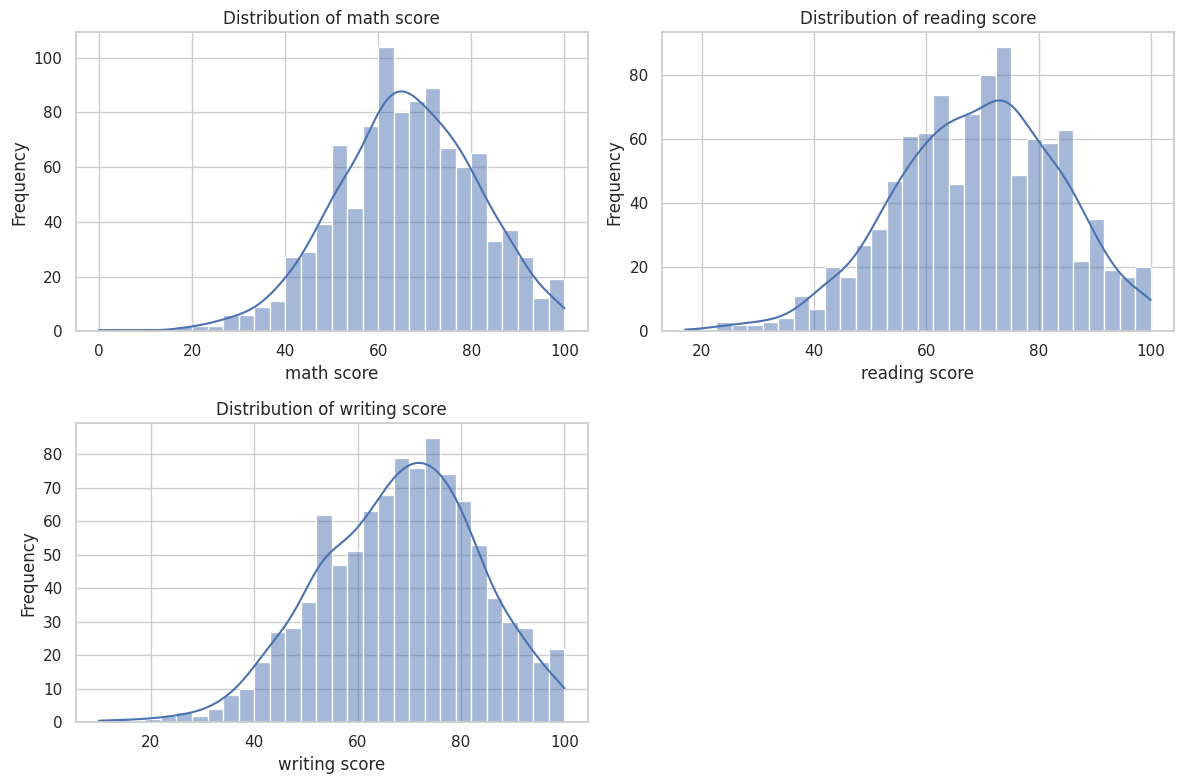

In [7]:
# Distribution of numeric scores
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

fig.delaxes(axes[3])
plt.tight_layout()
plt.show()

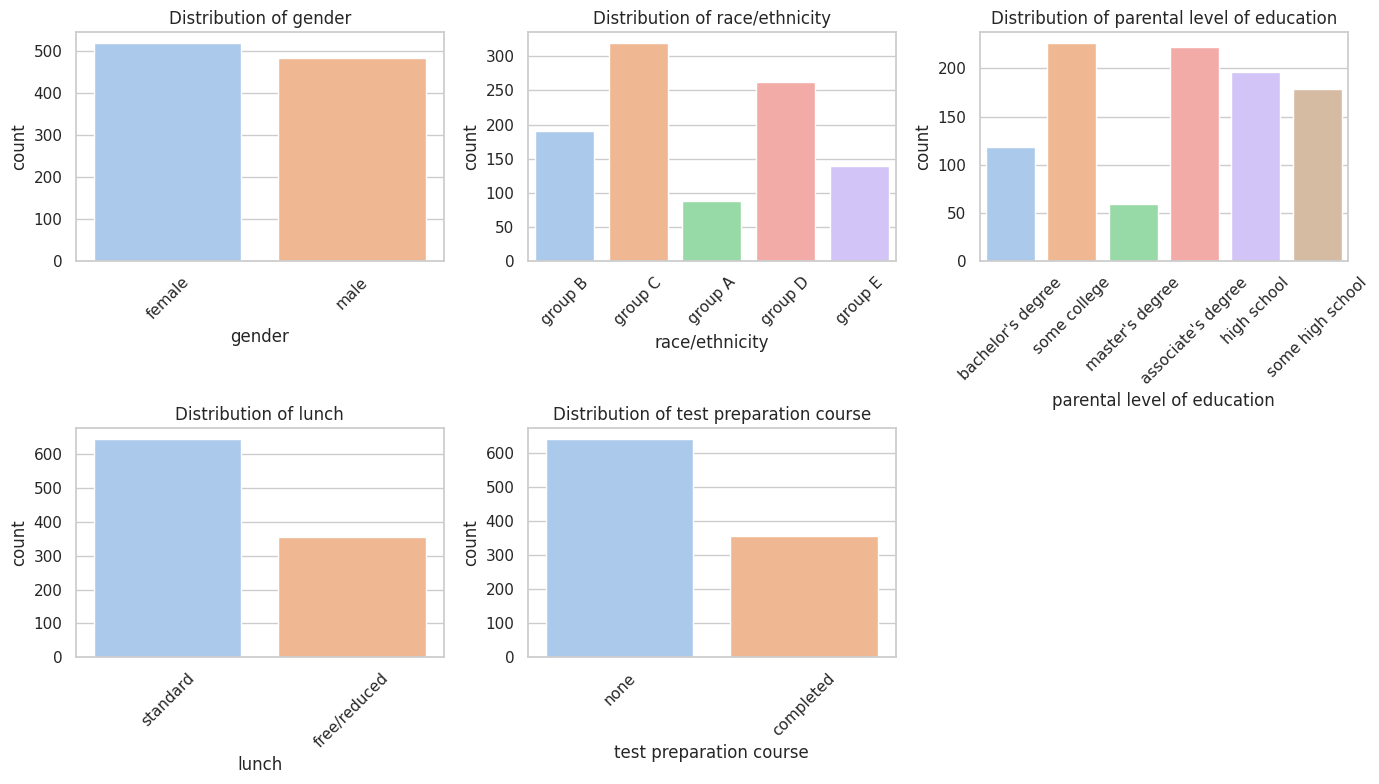

In [8]:
# Distribution of categorical features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, palette="pastel", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

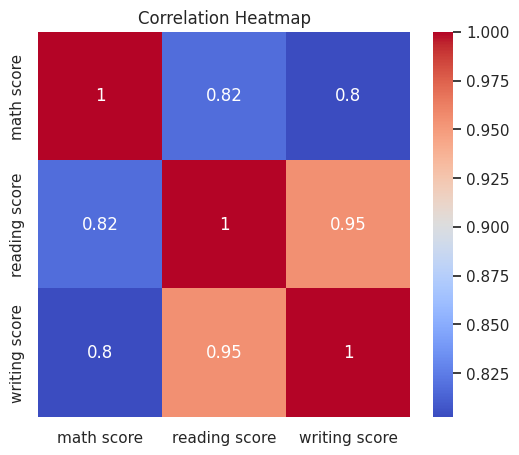

In [9]:
# Correlation between numeric features
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:** Reading and writing scores are **strongly correlated with math score** (and with each other), which is why they end up as the dominant predictors in the regression model. Categorical features are fairly balanced across groups, with `test preparation course` and `lunch` showing a visible link to score differences.

## 4. Preprocessing

Split the data first, then one-hot encode categorical columns (fit on train, transform on test) to avoid data leakage.

In [10]:
def split_data(df, target="math score", test_size=0.2, random_state=42):
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def encode_features(X_train, X_test, categorical_cols):
    encoder = OneHotEncoder(sparse_output=False, drop="first")
    encoder.fit(X_train[categorical_cols])

    def _encode(X):
        encoded = pd.DataFrame(
            encoder.transform(X[categorical_cols]),
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X.index,
        )
        return pd.concat([X.drop(columns=categorical_cols), encoded], axis=1)

    return _encode(X_train), _encode(X_test), encoder


X_train, X_test, y_train, y_test = split_data(df)
X_train_encoded, X_test_encoded, encoder = encode_features(X_train, X_test, categorical_cols)

print("Train shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Train shape: (800, 14)
Test shape: (200, 14)


## 5. Train the Linear Regression Model

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train_encoded, y_train)

y_pred = linear_model.predict(X_test_encoded)

train_score = linear_model.score(X_train_encoded, y_train)
test_score = linear_model.score(X_test_encoded, y_test)

print(f"Training R²: {train_score:.4f}")
print(f"Testing R²:  {test_score:.4f}")

Training R²: 0.8743
Testing R²:  0.8804


## 6. Model Evaluation

In [12]:
def evaluate(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


metrics = evaluate(y_test, y_pred)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 29.0952
MAE: 4.2148
RMSE: 5.3940
R2: 0.8804


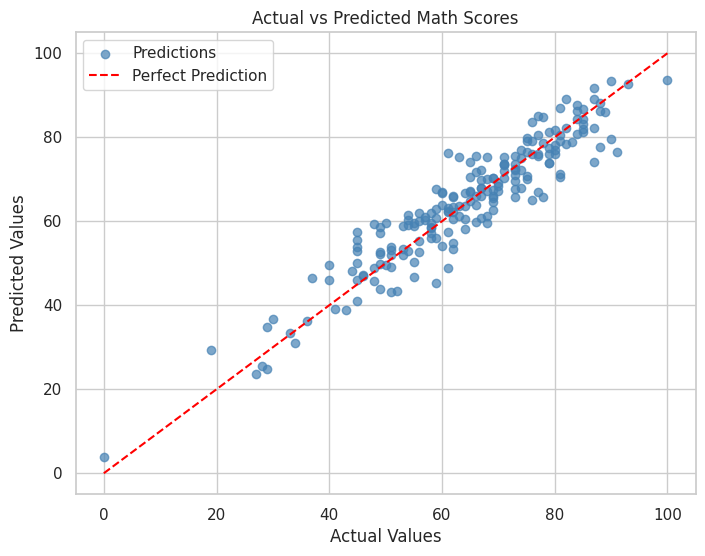

In [13]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="steelblue", alpha=0.7, label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linestyle="--", label="Perfect Prediction",
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Math Scores")
plt.legend()
plt.show()

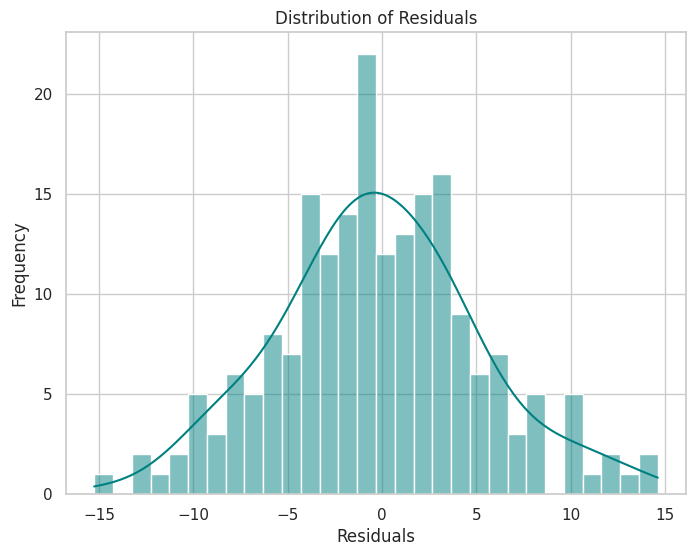

In [14]:
# Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color="teal")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

**Insight:** Train R² (0.874) and test R² (0.880) are close, so the model **generalizes well with no overfitting**. On average, predictions are off by about **4.2 points (MAE)** / **5.4 points (RMSE)** on a 0–100 scale — a solid fit for a simple linear model. Residuals are roughly centered around zero and normally distributed, meaning the model isn't systematically biased.

## 7. Predict for a New Student

In [15]:
def predict_math_score(student_dict, model, encoder, categorical_cols):
    student_df = pd.DataFrame(student_dict)
    encoded = pd.DataFrame(
        encoder.transform(student_df[categorical_cols]),
        columns=encoder.get_feature_names_out(categorical_cols),
    )
    student_encoded = pd.concat(
        [student_df.drop(columns=categorical_cols).reset_index(drop=True), encoded],
        axis=1,
    )
    return model.predict(student_encoded)[0]


new_student = {
    "gender": ["female"],
    "race/ethnicity": ["group B"],
    "parental level of education": ["bachelor's degree"],
    "lunch": ["standard"],
    "test preparation course": ["completed"],
    "reading score": [90],
    "writing score": [92],
}

predicted_score = predict_math_score(new_student, linear_model, encoder, categorical_cols)
print(f"Predicted Math Score for New Student: {predicted_score:.2f}")

Predicted Math Score for New Student: 80.10


## 8. Summary

- Clean dataset (no missing values/duplicates) with 1000 students.
- Reading and writing scores are the strongest predictors of math score.
- Linear Regression achieves **R² ≈ 0.88** on test data, MAE ≈ 4.2, RMSE ≈ 5.4 — a good, non-overfit baseline model.
- Example prediction: a student with 90 reading / 92 writing scores is predicted to score **≈ 80** in math.